In [1]:
import os

from superfv import OutputLoader

import matplotlib.pyplot as plt
import numpy as np

In [2]:
base_path = "/scratch/gpfs/TEYSSIER/jp7427/out/timing-of-2d-sine-wave/"
N_values = [32, 64, 128, 256, 512, 1024, 2048, 3072]

In [3]:
cache = {}

In [4]:
def plot_timings(name, ax, limiting_type, timing_type, style):
    timings = []

    for N in N_values:
        sim_path = f"{base_path}{name}/N_{N}"

        if not os.path.exists(sim_path):
            continue

        if sim_path not in cache:
            cache[sim_path] = {}

            sim = OutputLoader(sim_path)

            # get cell update rate
            mean_update_rate = np.mean(sim.minisnapshots["update_rate"][1:])
            cache[sim_path]["update"] = mean_update_rate

            # get riemann solver update rate
            riemann_times = [
                timer.data["integrate_fluxes:riemann_solver"].cum_time
                for timer in sim.minisnapshots["stepper_timer"]
            ]
            mean_riemann_rate = N * N / np.mean(np.array(riemann_times[1:]))
            cache[sim_path]["riemann"] = mean_riemann_rate

            # get slope limiter update rate
            if limiting_type == "none":
                riemann_times = [
                    timer.data["integrate_fluxes:riemann_solver"].cum_time
                    for timer in sim.minisnapshots["stepper_timer"]
                ]
                limiter_times = 0.0 * np.array(riemann_times)
            elif limiting_type == "muscl":
                limiter_times = [
                    timer.data["reconstruct_muscl_faces"].cum_time
                    for timer in sim.minisnapshots["stepper_timer"]
                ]
            elif limiting_type == "zs":
                zs_times = [
                    timer.data["zhang_shu_limiter"].cum_time
                    for timer in sim.minisnapshots["stepper_timer"]
                ]
                shock_detector_times = [
                    timer.data["update_workspaces:shock_detector"].cum_time
                    for timer in sim.minisnapshots["stepper_timer"]
                ]
                limiter_times = np.array(zs_times) + np.array(shock_detector_times)
            elif limiting_type == "mood":
                limiter_times = np.array(
                    [
                        timer.data["MOOD_loop"].cum_time
                        for timer in sim.minisnapshots["stepper_timer"]
                    ]
                )
            else:
                raise ValueError(f"Unknown limiting_type: {limiting_type}")

            mean_limiter_rate = N * N / np.mean(limiter_times[1:])
            cache[sim_path]["limiting"] = mean_limiter_rate

        if timing_type not in cache[sim_path]:
            raise ValueError(f"Could not find timings for the key {timing_type=}.")
        timings.append(cache[sim_path][timing_type])
    _style = dict(label=name.replace("cupy/", "")) | style
    ax.plot([N_values[i] for i in range(len(timings))], timings, **_style)

Successfully read simulation output from "/scratch/gpfs/TEYSSIER/jp7427/out/timing-of-2d-sine-wave/cupy/p0/N_32"
Successfully read simulation output from "/scratch/gpfs/TEYSSIER/jp7427/out/timing-of-2d-sine-wave/cupy/p0/N_64"
Successfully read simulation output from "/scratch/gpfs/TEYSSIER/jp7427/out/timing-of-2d-sine-wave/cupy/p0/N_128"
Successfully read simulation output from "/scratch/gpfs/TEYSSIER/jp7427/out/timing-of-2d-sine-wave/cupy/p0/N_256"
Successfully read simulation output from "/scratch/gpfs/TEYSSIER/jp7427/out/timing-of-2d-sine-wave/cupy/p0/N_512"
Successfully read simulation output from "/scratch/gpfs/TEYSSIER/jp7427/out/timing-of-2d-sine-wave/cupy/p0/N_1024"
Successfully read simulation output from "/scratch/gpfs/TEYSSIER/jp7427/out/timing-of-2d-sine-wave/cupy/p0/N_2048"
Successfully read simulation output from "/scratch/gpfs/TEYSSIER/jp7427/out/timing-of-2d-sine-wave/cupy/p0/N_3072"
Successfully read simulation output from "/scratch/gpfs/TEYSSIER/jp7427/out/timing-of-2

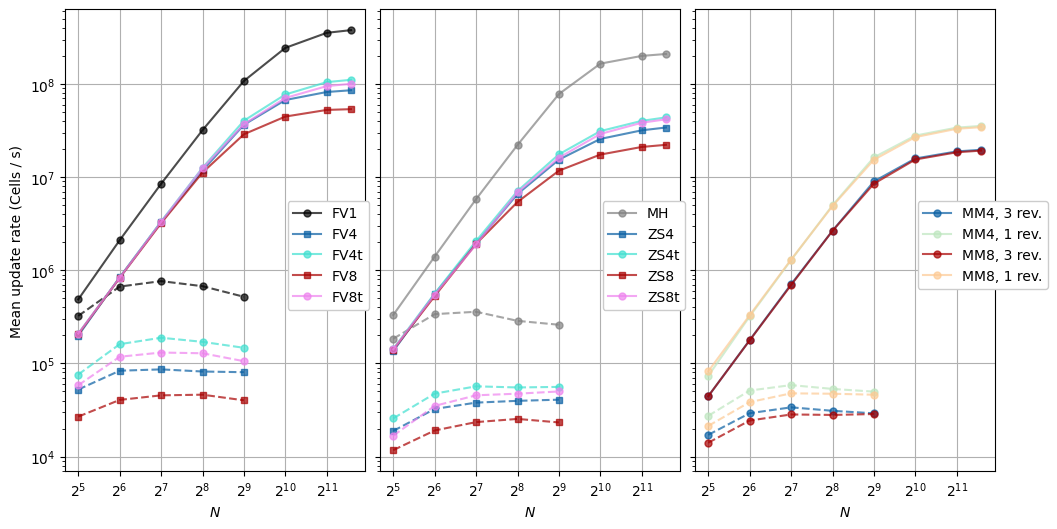

In [5]:
fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(12, 6))
axs[0].set_xscale("log", base=2)
axs[0].set_yscale("log")
for j in range(3):
    axs[j].set_xlabel(r"$N$")
    axs[j].grid()
axs[0].set_ylabel("Mean update rate (Cells / s)")

common = dict(markersize=5, alpha=0.7)
cmap1 = plt.get_cmap("GnBu")
cmap2 = plt.get_cmap("OrRd")

timing_type = "update"

plot_timings(
    "cupy/p0",
    axs[0],
    "none",
    timing_type,
    dict(label="FV1", color="k", marker="o", linestyle="-", **common),
)
plot_timings(
    "p0",
    axs[0],
    "none",
    timing_type,
    dict(label=None, color="k", marker="o", linestyle="--", **common),
)
plot_timings(
    "cupy/p3/GL",
    axs[0],
    "zs",
    timing_type,
    dict(label="FV4", color=cmap1(0.9), marker="s", linestyle="-", **common),
)
plot_timings(
    "p3/GL",
    axs[0],
    "zs",
    timing_type,
    dict(label=None, color=cmap1(0.9), marker="s", linestyle="--", **common),
)
plot_timings(
    "cupy/p3",
    axs[0],
    "none",
    timing_type,
    dict(label="FV4t", color="turquoise", marker="o", linestyle="-", **common),
)
plot_timings(
    "p3",
    axs[0],
    "none",
    timing_type,
    dict(label=None, color="turquoise", marker="o", linestyle="--", **common),
)
plot_timings(
    "cupy/p7/GL",
    axs[0],
    "zs",
    timing_type,
    dict(label="FV8", color=cmap2(0.9), marker="s", linestyle="-", **common),
)
plot_timings(
    "p7/GL",
    axs[0],
    "zs",
    timing_type,
    dict(label=None, color=cmap2(0.9), marker="s", linestyle="--", **common),
)
plot_timings(
    "cupy/p7",
    axs[0],
    "none",
    timing_type,
    dict(label="FV8t", color="violet", marker="o", linestyle="-", **common),
)
plot_timings(
    "p7",
    axs[0],
    "none",
    timing_type,
    dict(label=None, color="violet", marker="o", linestyle="--", **common),
)

plot_timings(
    "cupy/MUSCL-Hancock",
    axs[1],
    "muscl",
    timing_type,
    dict(label="MH", color="grey", marker="o", linestyle="-", **common),
)
plot_timings(
    "MUSCL-Hancock",
    axs[1],
    "muscl",
    timing_type,
    dict(label=None, color="grey", marker="o", linestyle="--", **common),
)
plot_timings(
    "cupy/ZS3",
    axs[1],
    "zs",
    timing_type,
    dict(label="ZS4", color=cmap1(0.9), marker="s", linestyle="-", **common),
)
plot_timings(
    "ZS3",
    axs[1],
    "zs",
    timing_type,
    dict(label=None, color=cmap1(0.9), marker="s", linestyle="--", **common),
)
plot_timings(
    "cupy/ZS3t",
    axs[1],
    "zs",
    timing_type,
    dict(label="ZS4t", color="turquoise", marker="o", linestyle="-", **common),
)
plot_timings(
    "ZS3t",
    axs[1],
    "zs",
    timing_type,
    dict(label=None, color="turquoise", marker="o", linestyle="--", **common),
)
plot_timings(
    "cupy/ZS7",
    axs[1],
    "zs",
    timing_type,
    dict(label="ZS8", color=cmap2(0.9), marker="s", linestyle="-", **common),
)
plot_timings(
    "ZS7",
    axs[1],
    "zs",
    timing_type,
    dict(label=None, color=cmap2(0.9), marker="s", linestyle="--", **common),
)
plot_timings(
    "cupy/ZS7t",
    axs[1],
    "zs",
    timing_type,
    dict(label="ZS8t", color="violet", marker="o", linestyle="-", **common),
)
plot_timings(
    "ZS7t",
    axs[1],
    "zs",
    timing_type,
    dict(label=None, color="violet", marker="o", linestyle="--", **common),
)

plot_timings(
    "cupy/MM3/3revs/rtol_0",
    axs[2],
    "mood",
    timing_type,
    dict(label="MM4, 3 rev.", color=cmap1(0.9), marker="o", linestyle="-", **common),
)
plot_timings(
    "MM3/3revs/rtol_0",
    axs[2],
    "mood",
    timing_type,
    dict(label=None, color=cmap1(0.9), marker="o", linestyle="--", **common),
)
plot_timings(
    "cupy/MM3/1rev/rtol_0",
    axs[2],
    "mood",
    timing_type,
    dict(label="MM4, 1 rev.", color=cmap1(0.3), marker="o", linestyle="-", **common),
)
plot_timings(
    "MM3/1rev/rtol_0",
    axs[2],
    "mood",
    timing_type,
    dict(label=None, color=cmap1(0.3), marker="o", linestyle="--", **common),
)
plot_timings(
    "cupy/MM7/3revs/rtol_0",
    axs[2],
    "mood",
    timing_type,
    dict(label="MM8, 3 rev.", color=cmap2(0.9), marker="o", linestyle="-", **common),
)
plot_timings(
    "MM7/3revs/rtol_0",
    axs[2],
    "mood",
    timing_type,
    dict(label=None, color=cmap2(0.9), marker="o", linestyle="--", **common),
)
plot_timings(
    "cupy/MM7/1rev/rtol_0",
    axs[2],
    "mood",
    timing_type,
    dict(label="MM8, 1 rev.", color=cmap2(0.3), marker="o", linestyle="-", **common),
)
plot_timings(
    "MM7/1rev/rtol_0",
    axs[2],
    "mood",
    timing_type,
    dict(label=None, color=cmap2(0.3), marker="o", linestyle="--", **common),
)

for ax in axs:
    ax.legend(loc="upper left", bbox_to_anchor=(0.72, 0.6), framealpha=1)

plt.subplots_adjust(wspace=0.05)

In [6]:
fig.savefig("GPU-CPU_update_rates_one-row.pdf", bbox_inches="tight")